## Looking for combinations of OWFs that have the most/the least effect on connectivity ## 

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import networkx as nx
import csv
import json
import geopandas as gpd
import numpy as np
import math
from itertools import combinations
import json

with open(f"Graph_json/Graph_mean_farm_and_coast_PD60.json", "r") as f:
    data = json.load(f)
G = nx.node_link_graph(data)

farm_file = '/projappl/project_2018610/data/DTO4OWE_polygons/Wind_farms_Bothnian_Sea.shp'
coast_file = '/projappl/project_2018610/data/coastal/nemo_nordic_10-20m_polygons.shp'
gdf_farm = gpd.read_file(farm_file)
gdf_coast = gpd.read_file(coast_file)

farmIDs = np.arange(1, 20)
coastIDs = gdf_coast.sort_values('fid')['ID'].astype(str).tolist() # creating a list of coastal areas sorted by fid
nb_f = 19 # number of OWF
nb_c = 26 # number of coastal areas

In [2]:
H = G.copy()
for nd in list(H.nodes()):
    if (nd, nd) in list(H.edges()):       
        H.remove_edge(nd, nd)
for e in list(H.edges()):
    H.edges[e[0], e[1]]['weight'] = - math.log(G.edges[e[0], e[1]]['prob'])
    # the path is shorter when the probability is higher, using log because we need to multiply probabilities

In [3]:
# creating a dictionnary with all possible combinaisons
farmIDs = list(range(1, 20))  # 19 items, e.g. farm IDs 1..19

combination = {i: {} for i in range(1, 19)}  # exclude 19

for size in range(1, 19):
    for combo in combinations(farmIDs, size):
        # readable, unique ID: e.g. "3_1-4-9" = size 3, farms 1,4,9
        combo_id = f"{size}_" + "-".join(map(str, combo))
        combination[size][combo_id] = []
        combination[size][combo_id].append(list(combo)) 

In [4]:
regions = {'N_FI':['FI4', 'FI3', 'FI2', 'FI1', 'FI0'],
           'S_FI':['FI8', 'FI7', 'FI6', 'FI5'],           
           'A': ['A1', 'A2', 'A3'],
           'SE_F':['SE10', 'SE11'],
           'S_SE':['SE07', 'SE08', 'SE09', 'SE12', 'SE13', 'SE14'],
           'N_SE': ['SE01', 'SE02', 'SE03', 'SE04', 'SE05', 'SE06']}

### "Best combinations" ###
Combinations of OWFs with the most effects on connectivity between coastal areas

In [29]:
# Looking for the combination that increases the most the mean indirect connectivity in the region
with open('best_combinations.json') as json_file:
    best_combinations = json.load(json_file)
    
n = 17 # size of the combination
for region in regions.keys():
    print(f'region : {region}')
    
    # calculating the initial value of indirect connectivity
    H_without = H.copy()
    for farm in farmIDs:
        H_without.remove_node(str(farm))   
    prob = {}
    sum_prob = 0
    cpt = 0
    for i, source in enumerate(coastIDs) :
        for j, dest in enumerate(coastIDs) :
            if source != dest and (source in regions[region] or dest in regions[region]):
                sum_log = nx.dijkstra_path_length(H_without, source, dest, weight='weight')                
                sum_prob += math.exp(-sum_log)
                cpt += 1
    initial_value = sum_prob/cpt
    
    # calculating the increase of mean indirect connectivity
    
    # removing farms that are not in the combinaison
    combos = combination[n]
    max_prob = 0
    for combo_id in combos.keys():
        H_with = H.copy()
        removed_farms = []
        for farm in farmIDs:
            if farm not in combos[combo_id][0]:
                removed_farms.append(str(farm))
        H_with.remove_nodes_from(removed_farms)
    
        sum_prob = 0
        cpt = 0
        for i, source in enumerate(coastIDs) :
            for j, dest in enumerate(coastIDs) :
                if source != dest and (source in regions[region] or dest in regions[region]):
                    sum_log = nx.dijkstra_path_length(H_with, source, dest, weight='weight')               
                    sum_prob += math.exp(-sum_log)
                    cpt += 1
        increase = sum_prob*100/(cpt*initial_value) - 100
        if increase > max_prob :
            max_combo = combo_id
            max_prob = increase
            print(f'new best combo : {combo_id} +{increase}%')
    
    best_combinations[str(n)][region] = {'combo_id' : max_combo, 'increase' : max_prob} 

region : N_FI
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17 +1.1812271095300702%
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-18 +1.2672327200781695%
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-18-19 +1.3218524538703633%
region : S_FI
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17 +2.9930864476561965%
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-18 +3.11988784337089%
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-18-19 +3.1199350711835336%
region : A
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17 +5.019457056696851%
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-18 +5.058766335590008%
region : SE_F
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17 +30.015665919214456%
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-18 +30.02111343887489%
region : S_SE
new best combo : 17_1-2-3-4-5-6-7-8-9-10-11-12-13-14-15-16-17 +8.356195169507771%
new best combo : 17_1-2-3-

In [6]:
# print(best_combinations)

In [18]:
with open("best_combinations.json", "w") as f:
    f.write(json.dumps(best_combinations))

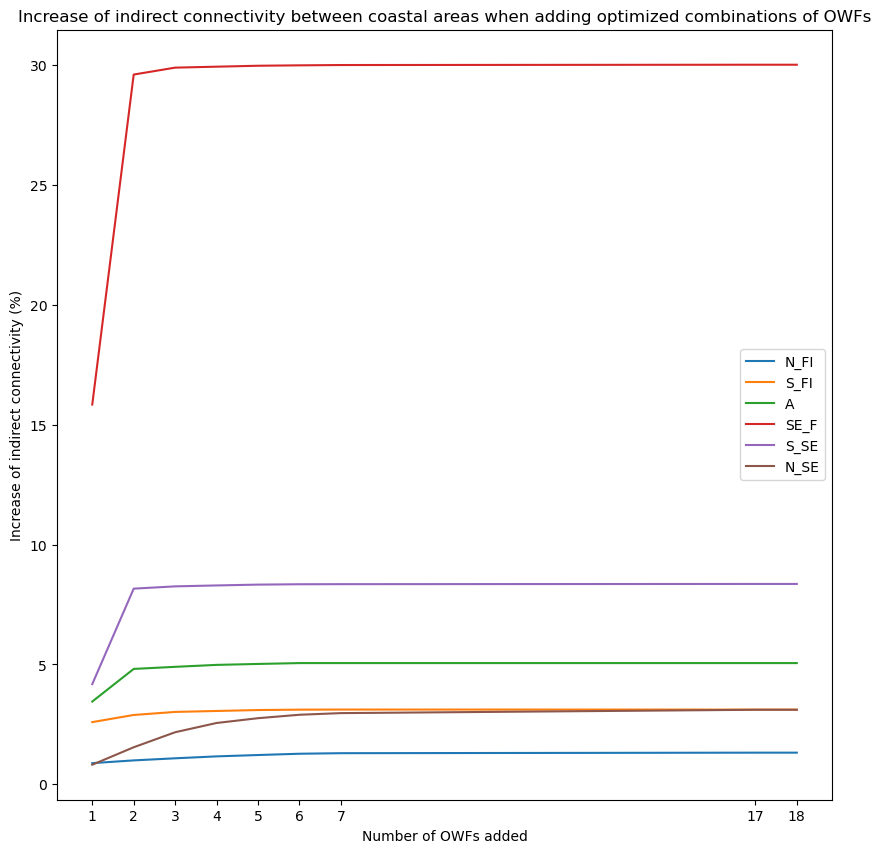

In [24]:
nb_farms = nb_farms = np.array([1, 2, 3, 4, 5, 6, 7, 17, 18])
fig, ax = plt.subplots(figsize=(10, 10))
for region in regions.keys():
    prob = []
    for n in nb_farms :
        prob.append(best_combinations[str(n)][region]['increase'])
    plt.plot(nb_farms, prob, label=f'{region}')

ax.legend()
plt.xticks(nb_farms, nb_farms)
ax.set_title(f'Increase of indirect connectivity between coastal areas when adding optimized combinations of OWFs')
ax.set_xlabel("Number of OWFs added")
ax.set_ylabel("Increase of indirect connectivity (%)")
plt.show()
fig.savefig(f'shortest_path/Increase_indirect_connectivity_best_combinations')
        

### "Worst combinations" ###
Combinations of OWFs with the least effects on connectivity between coastal areas

In [5]:
with open('worst_combinations.json') as json_file:
    worst_combinations = json.load(json_file)

In [25]:
# Looking for the combination that limits the most the mean indirect connectivity in the region
n = 14 # size of the combination
for region in regions.keys():
    print(f'region : {region}')
    
    # calculating the initial value of indirect connectivity
    H_without = H.copy()
    for farm in farmIDs:
        H_without.remove_node(str(farm))   
    prob = {}
    sum_prob = 0
    cpt = 0
    for i, source in enumerate(coastIDs) :
        for j, dest in enumerate(coastIDs) :
            if source != dest and (source in regions[region] or dest in regions[region]):
                sum_log = nx.dijkstra_path_length(H_without, source, dest, weight='weight')                
                sum_prob += math.exp(-sum_log)
                cpt += 1
    initial_value = sum_prob/cpt
    
    # calculating the increase of mean indirect connectivity
    
    # removing farms that are not in the combinaison
    combos = combination[n]
    min_prob = 100
    for combo_id in combos.keys():
        H_with = H.copy()
        removed_farms = []
        for farm in farmIDs:
            if farm not in combos[combo_id][0]:
                removed_farms.append(str(farm))
        H_with.remove_nodes_from(removed_farms)
    
        sum_prob = 0
        cpt = 0
        for i, source in enumerate(coastIDs) :
            for j, dest in enumerate(coastIDs) :
                if source != dest and (source in regions[region] or dest in regions[region]):
                    sum_log = nx.dijkstra_path_length(H_with, source, dest, weight='weight')               
                    sum_prob += math.exp(-sum_log)
                    cpt += 1
        increase = sum_prob*100/(cpt*initial_value) - 100
        if increase < min_prob :
            min_combo = combo_id
            min_prob = increase
            print(f'new worst combo : {combo_id} +{increase}%')
    
    worst_combinations[str(n)][region] = {'combo_id' : min_combo, 'increase' : min_prob} 

region : N_FI
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-13-14 +1.1169007086897267%
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-13-16 +1.0459172311281861%
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-14-15 +0.40000977116925185%
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-14-16 +0.3406801513636424%
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-15-16 +0.3264574685186403%
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-16-17 +0.21605486080656533%
new worst combo : 14_2-3-4-5-6-7-8-9-10-11-12-16-17-18 +0.20915787416925014%
new worst combo : 14_2-3-4-5-6-7-8-9-10-11-12-16-17-19 +0.1869704788343114%
region : S_FI
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-13-14 +2.9769307180268925%
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-13-15 +2.967881091783582%
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-13-16 +2.9363727021816146%
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-14-15 +0.3953275061810615%
new worst combo : 14_1-2-3-4-5-6-7-8-9-10-11-12-14-16 +0.37916332615

In [26]:
with open("worst_combinations.json", "w") as f:
    f.write(json.dumps(worst_combinaisons))

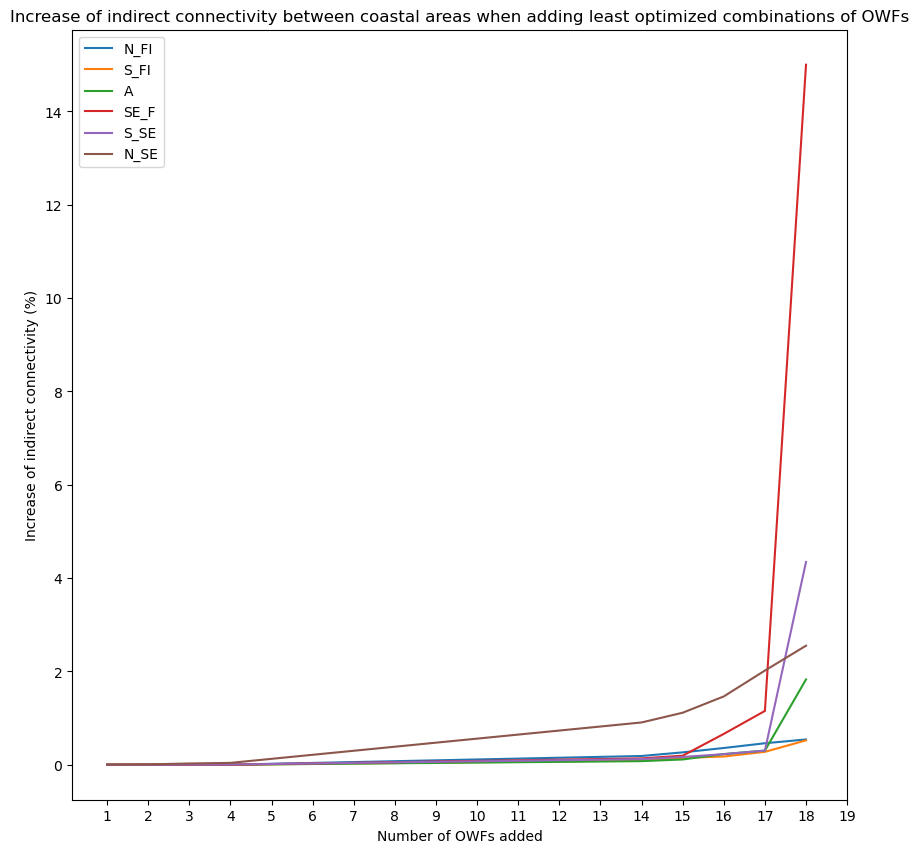

In [30]:
nb_farms = np.array([1, 2, 3, 4, 14, 15, 16, 17, 18])
fig, ax = plt.subplots(figsize=(10, 10))
for region in regions.keys():
    prob = []
    for n in nb_farms :
        prob.append(worst_combinations[str(n)][region]['increase'])
    plt.plot(nb_farms, prob, label=f'{region}')

plt.xticks(farmIDs, farmIDs)
ax.legend()
ax.set_title(f'Increase of indirect connectivity between coastal areas when adding least optimized combinations of OWFs')
ax.set_xlabel("Number of OWFs added")
ax.set_ylabel("Increase of indirect connectivity (%)")
plt.show()
fig.savefig(f'shortest_path/Increase_indirect_connectivity_worst_combinations')